# 23 · DLM em painel: escolha do horizonte por AIC
Isabella Viana Bambirra · Estatística/UFSCar · revisão solicitada em 06/10/2026.

Referência atual: escolher separadamente **K=1,...,24** por exposição e período. A versão K6 do notebook 22 permanece histórica. Granger não é reestimado; SARIMAX não é executado. O capítulo orienta o DLM clássico; os dados atuais definem recortes e unidade.

A pergunta é se mudanças logarítmicas dos registros de desastres se associam às mudanças logarítmicas da inadimplência contemporânea e nos meses seguintes, com efeitos fixos de UF e mês-ano. AIC escolhe o horizonte do ajuste; não estabelece duração física ou causalidade.

In [1]:
from pathlib import Path
import sys,json
import numpy as np,pandas as pd
from threadpoolctl import threadpool_limits
ROOT=Path.cwd()
if ROOT.name=='notebooks':ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'src'))
import dlm_painel_log_aic as m
print('Candidatos: K=1,...,24; contemporâneo incluído; DK fixo em',m.DK_L)
print((ROOT/'docs/dlm_painel_log_historico.json').read_text())

Candidatos: K=1,...,24; contemporâneo incluído; DK fixo em 6
[
  {
    "branch": "main",
    "sha": "027ee8aa245494765d99bff2511b6f60b30ddf41",
    "agentes": [],
    "notebooks_dlm": []
  },
  {
    "branch": "analise/dlm",
    "sha": "3c94482628b86d1789ee98f8d35f6820835a7219",
    "agentes": [],
    "notebooks_dlm": [
      "notebooks/16_modelos_defasagens_distribuidas.ipynb"
    ]
  },
  {
    "branch": "analise/dlm-revisao-metodologica",
    "sha": "c64589abc0f886a4e55e73b32328f8b0206376aa",
    "agentes": [],
    "notebooks_dlm": [
      "notebooks/16_modelos_defasagens_distribuidas.ipynb",
      "notebooks/17_revisao_metodologica_dlm.ipynb"
    ]
  },
  {
    "branch": "analise/dlm-validacao-final",
    "sha": "87bee9689528b9d273c660ed2aff19c4739d8c54",
    "agentes": [],
    "notebooks_dlm": [
      "notebooks/16_modelos_defasagens_distribuidas.ipynb",
      "notebooks/17_revisao_metodologica_dlm.ipynb",
      "notebooks/18_validacao_final_dlm.ipynb"
    ]
  },
  {
    "branch":

## 1. Desenho e regras definidas antes da execução
$$y_{it}=\Delta\log(I_{it}),\quad x_{it}=\Delta\log(1+D_{it}),\qquad y_{it}=\alpha_i+\lambda_t+\sum_{k=0}^{K^*}\beta_kx_{i,t-k}+\varepsilon_{it}.$$

27 UFs, sem ponderação; todos estados ficam nos modelos. São efeitos fixos completos de mês-ano, não 11 dummies sazonais. Sem lags de y, spline ou regime. Um modelo por exposição, sem incluir categorias sobrepostas simultaneamente.

K* minimiza o AIC na amostra comum elegível para K24. Manter essa amostra no modelo escolhido separa a mudança de K da mudança de dados. p, IC e BH usuais tratam o K selecionado como fixo e ignoram a incerteza de seleção. Não houve inferência seletiva formal; as rejeições são exploratórias. AIC gaussiano é um critério de trabalho sob dependência residual.

In [2]:
print((ROOT/'docs/dlm_painel_log_aic_protocolo.md').read_text())

# Referência atual: DLM em painel com K escolhido por AIC entre 1 e 24

Revisão solicitada em 06/10/2026, registrada antes desta execução. Substitui a escolha fixa K6 como referência; notebook 22 e suas saídas permanecem históricos, sem alteração. O pedido completo foi recuperado. Main de partida: ba0865e, versão K6 já publicada. Nenhum AGENTS.md foi encontrado em main ou nas quatro branches DLM listadas no histórico. Capítulo de metodologia preservado; não refazer Granger nem executar SARIMAX.

## Equação e seleção

y_it = Δlog(I_it), x_it = Δlog(1+D_it).

y_it = α_i + λ_t + Σ(k=0..K*) β_k x_i,t−k + ε_it.

K* = argmin(K=1,...,24) AIC(K), separadamente por exposição e período. Cada candidato inclui o contemporâneo e todos os lags de 1 até K; não seleciona lags isolados. Coeficientes livres, MQO não ponderado, 27 UFs, efeitos fixos de UF e mês-ano completos; sem defasagem de y, spline ou regimes. O mesmo K vale para as UFs de uma aplicação, mas pode mudar entre desastres e recortes. A s

## 2. Crédito, calendário e fonte da exposição
Conferir 27×144 células, chave única, TI=100CI/CA e carteiras positivas. Ausência não vira zero. Conferir hashes das entradas com a execução histórica antes de reusar a medida administrativa. D é contagem de linhas do Atlas, não eventos físicos únicos ou intensidade. Identificador: hash da fonte + número de linha. Agregação por Data_Evento.

Total climático selecionado uma única vez por COBRADE 12/13/14; grupos e tipologias Atlas complementares. Não somar categorias sobrepostas.

In [3]:
old=json.loads((ROOT/'outputs/tables/dlm_painel_log/manifest.json').read_text())
for path,h in old['inputs'].items():
    if path.startswith('data/'):assert m.sha(ROOT/path)==h,path
d,labels=m.audit()
print(pd.read_csv(m.OUT/'auditoria.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'reconciliacao_atlas.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'taxonomia.csv').to_string(index=False))

   N  UFs  meses  registros  climaticos  repeticoes_chave  protocolos_repetidos  protocolos_ausentes  datas_invalidas  max_diferenca_TI                                                 identificador data_agregacao                                                                        zeros
3888   27    144      40339       37643               101                     0                    0                0      1.776357e-15 sha256 fonte + linha original (cabeçalho=1); não deduplicar A    Data_Evento Ausência de linha na fonte conciliada, não ausência de observação de crédito
                              coluna  total_atlas  total_painel  max_diferenca
                     total_desastres        40339         40339              0
                 grupo_climatologico        19518         19518              0
                   grupo_hidrologico        15409         15409              0
                 grupo_meteorologico         3716          3716              0
                        g

**Leitura:** contagens administrativas conciliadas preservam comparabilidade com o notebook 22. Biológicos, tecnológicos e geológicos ficam fora do central, ainda que chuva possa desencadear movimentos de massa. Rótulos Chuvas Intensas/Onda de Frio/Baixa Umidade têm ambiguidades de códigos documentadas. Isso impede atribuir todos rótulos diretamente a fenômenos climáticos homogêneos ou ao aquecimento antropogênico.

## 3. Estacionariedade das séries transformadas por UF
Primeiro log, depois diferença, dentro da UF e do recorte; nunca log de uma diferença que pode ser negativa.

ADF: $\Delta z_t=c+\gamma z_{t-1}+\sum_j\phi_j\Delta z_{t-j}+u_t$, $H_0:\gamma=0$ (raiz unitária), $H_1:\gamma<0$.

KPSS: $z_t=c+r_t+u_t$, $r_t=r_{t-1}+\eta_t$, $H_0:\operatorname{Var}(\eta)=0$ (estacionariedade em torno do intercepto), $H_1:\operatorname{Var}(\eta)>0$.

ADF com intercepto/AIC; KPSS intercepto/banda auto. Ambos não rejeitar é inconclusivo; não rejeição KPSS não confirma estacionariedade. Reportar limites tabulares, constantes, lags e n. Diagnóstico sobre séries completas transformadas no recorte, não certificado específico da subamostra de seleção.

In [4]:
st=m.stationarity(d,labels)
print(st.groupby(['periodo','exposicao','classificacao']).size().to_string())
print(st[(st.exposicao=='inadimplencia') & (st.classificacao=='desfavorável')][['periodo','uf','ADF_p','KPSS_p']].to_string(index=False))

periodo  exposicao                             classificacao
Pré      grupo_climatologico                   divergente        2
                                               favorável        20
                                               indisponível      5
         grupo_hidrologico                     divergente        1
                                               favorável        25
                                               indisponível      1
         grupo_meteorologico                   divergente        1
                                               favorável        15
                                               inconclusivo      1
                                               indisponível     10
         grupo_outros                          divergente        7
                                               favorável        13
                                               indisponível      7
         inadimplencia                         desfavorável      2
 

/workspace/scratch/3e7290c94e17/tcc/src/dlm_painel_log_aic.py:85: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  ad=adfuller(s,maxlag=ml,regression='c',autolag='AIC');base.update(ADF_estatistica=ad[0],ADF_p=ad[1],ADF_lag=ad[2],ADF_n=ad[3],ADF_IC=ad[5],**{'ADF_crit_'+k:v for k,v in ad[4].items()})
/workspace/scratch/3e7290c94e17/tcc/src/dlm_painel_log_aic.py:85: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current be

**Leitura:** Δlog(I) permanece inconclusiva em 19 UFs no pré e 8 no total; desfavorável em RO/SC no pré e RO no total. Preservar a transformação não transforma os diagnósticos em favoráveis. FE e erros robustos não corrigem raiz unitária. CIPS histórico em ΔI/cobertura e diagnóstico nacional não validam estas séries estaduais. A análise permanece exploratória.

## 4. Todos os candidatos em amostra comum
$$\operatorname{AIC}(K)=n[\log(2\pi)+1+\log(\operatorname{SQR}_K/n)]+2[27+T-1+(K+1)].$$

A escala não entra na contagem, seguindo OLSResults; incluir a escala adicionaria constante 2 a todos AIC. FE são contados. Minimizar AIC separado por exposição/recorte, empate numérico 1e−8 favorece menor K; ΔAIC≤2 indica candidatos próximos, sem alterar a regra do mínimo.

Primeira equação fev/2015: perder 1 mês pela diferença e 24 pelos lags, total 675 células/recorte. Pré N=1620 (60×27), total N=3213 (119×27). Nenhum candidato recupera meses retirados. Verificar suporte tanto na janela original quanto na amostra comum, rank e condição; não usar pseudoinversa silenciosa.

In [5]:
with threadpool_limits(limits=1):r=m.estimate(d,labels,st)
print(pd.read_csv(m.OUT/'selecao_K.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'amostras_suporte.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'candidatos_AIC.csv').query("exposicao=='total_climatico'")[['periodo','K','N','AIC','delta_AIC','selecionado','status']].to_string(index=False))

Pré total_climatico K AIC 1 estimado
Pré grupo_climatologico K AIC 1 estimado
Pré grupo_hidrologico K AIC 1 estimado
Pré grupo_meteorologico K AIC 1 estimado
Pré grupo_outros K AIC 1 estimado
Pré tipo_alagamentos K AIC 1 estimado
Pré tipo_chuvas_intensas K AIC 15 estimado
Pré tipo_doencas_infecciosas K AIC 1 estimado
Pré tipo_enxurradas K AIC 1 estimado
Pré tipo_erosao K AIC 1 estimado
Pré tipo_estiagem_e_seca K AIC 1 estimado
Pré tipo_granizo K AIC 1 estimado
Pré tipo_incendio_florestal K AIC 1 estimado
Pré tipo_inundacoes K AIC 1 estimado
Pré tipo_movimento_de_massa K AIC 1 estimado
Pré tipo_outros K AIC 1 estimado
Pré tipo_tornado K AIC 1 estimado
Pré tipo_vendavais_e_ciclones K AIC 14 estimado
Total total_climatico K AIC 1 estimado
Total grupo_climatologico K AIC 1 estimado
Total grupo_hidrologico K AIC 1 estimado
Total grupo_meteorologico K AIC 9 estimado
Total grupo_outros K AIC 1 estimado
Total tipo_alagamentos K AIC 1 estimado
Total tipo_chuvas_intensas K AIC 16 estimado
Total 

In [6]:
sel=pd.read_csv(m.OUT/'selecao_K.csv')
print('Distribuição de K selecionado:')
print(sel.groupby(['periodo','K']).size().to_string())
print('Candidatos próximos não certificam um único horizonte:')
print(sel[['periodo','rotulo','K','K_delta_AIC_ate2','fronteira','status']].to_string(index=False))

Distribuição de K selecionado:
periodo  K   
Pré      1.0     16
         14.0     1
         15.0     1
Total    1.0     14
         4.0      1
         5.0      1
         6.0      1
         9.0      2
         14.0     1
         16.0     1
Candidatos próximos não certificam um único horizonte:
periodo                                                  rotulo    K K_delta_AIC_ate2 fronteira                  status
    Pré Total climático / hidrometeorológico (COBRADE 12/13/14)  1.0              1,2      True             selecionado
    Pré                                           Climatológico  1.0              1,2      True             selecionado
    Pré                                             Hidrológico  1.0              1,2      True             selecionado
    Pré                                           Meteorológico  1.0           1,2,14      True             selecionado
    Pré                                                  Outros  1.0              1,2      True     

**Interpretação:** K pode diferir entre desastres e períodos, mas não precisa. K1/K24 são limites da grade, não duração comprovada; no limite superior o horizonte pode estar truncado. Somatórios com K distintos são associações acumuladas em horizontes distintos. A seleção é pelo ajuste, jamais pelo menor p.

## 5. Validação independente e diagnósticos
CR1 por UF, correção G/(G−1)×(n−1)/(n−p_total), t26/Wald F(r,26). DK6, scores mensais/Bartlett, n/(n−p_total), t(T−1)/F(r,T−1). A banda DK6 é fixa e diferente de K do DLM. Cluster por UF não resolve dependência transversal.

Comparar FWL com dummies explícitas nas centrais (K selecionado e extremos 1/24), incluindo AIC, β e CR1; DK com statsmodels. Covariância da soma inclui todos elementos. Condicionamento, VIF, correlação dos lags, influência, autocorrelação e dependência residual são registrados, sem excluir UFs pelo p.

In [7]:
print(pd.read_csv(m.OUT/'validacao.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'diagnosticos.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'influencia_uf.csv').query("exposicao=='total_climatico'").sort_values('share_variancia_acumulado',ascending=False).head(8).to_string(index=False))

periodo       exposicao   nivel                                                  rotulo  K               uso   AIC_dummies       AIC_FWL  DK_statsmodels_max_diff  coef_FWL_dummies_max_diff  cov_CR1_dummies_max_diff     var_soma  soma_todas_covariancias  passou
    Pré total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14)  1       selecionado  -7060.965811  -7060.965811             4.499863e-22               4.038653e-18              3.705769e-22 6.008922e-07             6.008922e-07    True
    Pré total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14) 24 candidato extremo  -7032.193909  -7032.193909             8.300923e-20               2.775558e-17              3.227196e-19 3.607412e-04             3.607412e-04    True
  Total total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14)  1       selecionado -15035.596458 -15035.596458             1.720536e-22               5.746272e-18              2.117582e-22 4.

**Leitura dos diagnósticos:** testes residuais são descritivos e não certificam a regressão. CD ingênuo sob efeitos temporais não é calibrado; Levene pressupõe independência. Poucas UFs efetivamente expostas e K longos podem fragilizar testes conjuntos (25 coeficientes em K24 versus 27 clusters). DK não corrige exogeneidade, seleção de K ou estacionariedade.

## 6. Associações contemporâneas, defasadas e acumuladas
Reportar β0, soma0K, soma1K, conjuntos0K/1K, perfis e IC95% pontuais. $\operatorname{Var}(c'\hat\beta)=c'\hat Vc$, não soma dos erros padrão. BH por período×nível×covariância×endpoint; indisponíveis ficam na família apenas como p=1 no ajuste, sem p observado fictício. BH não remove seleção AIC.

In [8]:
print(r[r.exposicao=='total_climatico'][['periodo','K','covariancia','endpoint','estimate','low','high','p','q_BH']].to_string(index=False))
print('Todas rejeições BH, sem selecionar apenas favoráveis:')
print(r[r.q_BH<.05][['periodo','K','rotulo','covariancia','endpoint','estimate','p','q_BH']].to_string(index=False))
for per in m.PERIODS:
    z=r[(r.periodo==per)&(r.exposicao=='total_climatico')&(r.endpoint=='soma0K')]
    for row in z.itertuples():
        print(f'{per}, K={row.K}, {row.covariancia}: associação acumulada={row.estimate:.6f}, IC95%=[{row.low:.6f},{row.high:.6f}], p={row.p:.6f}, q={row.q_BH:.6f}. '+('Rejeição exploratória a 5%, ignorando a seleção de K.' if row.q_BH<.05 else 'Sem rejeição a 5%.'))

periodo   K covariancia   endpoint  estimate       low     high        p     q_BH
    Pré 1.0         CR1      beta0  0.000139 -0.000731 0.001008 0.745748 0.745748
    Pré 1.0         CR1     soma0K -0.000063 -0.001656 0.001531 0.936145 0.936145
    Pré 1.0         CR1     soma1K -0.000201 -0.001031 0.000628 0.621819 0.621819
    Pré 1.0         CR1 conjunto0K  0.713442       NaN      NaN 0.499297 0.499297
    Pré 1.0         CR1 conjunto1K  0.249225       NaN      NaN 0.621819 0.621819
    Pré 1.0         DK6      beta0  0.000139 -0.000651 0.000928 0.726540 0.726540
    Pré 1.0         DK6     soma0K -0.000063 -0.001920 0.001795 0.946366 0.946366
    Pré 1.0         DK6     soma1K -0.000201 -0.001353 0.000951 0.727759 0.727759
    Pré 1.0         DK6 conjunto0K  0.697140       NaN      NaN 0.502063 0.502063
    Pré 1.0         DK6 conjunto1K  0.122337       NaN      NaN 0.727759 0.727759
  Total 1.0         CR1      beta0  0.000623 -0.000134 0.001380 0.102900 0.102900
  Total 1.0     

**Interpretação:** sinal não basta para afirmar associação; não rejeição não prova ausência. Conjunto pode rejeitar e soma não, porque sinais opostos se compensam. Sensibilidade CR1/DK e suporte devem acompanhar p e q. P distintos em janelas sobrepostas não demonstram mudança temporal. Resultados usuais após seleção continuam exploratórios; não houve inferência seletiva formal.

## 7. Perfis e cenários na escala correta
β mede associação entre mudanças logarítmicas, não pontos percentuais ou elasticidade simples em D. C(h) soma β até h: resposta acumulada em log(I) a um pulso unitário em Δlog1p(D). Bandas pontuais, não simultâneas.

Aumento persistente 0→1 registro: pulso log2 na diferença. Pulso de um mês em D: +log2 seguido de −log2. Resposta é convolução com β; acumular em log(I), converter por 100[exp(resposta)−1]. São cenários algébricos condicionais, não previsão causal de desastre físico.

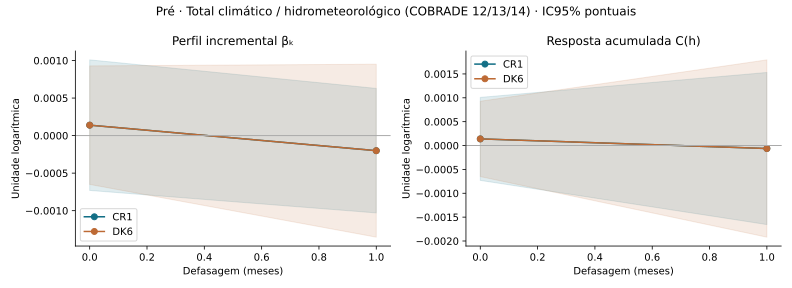

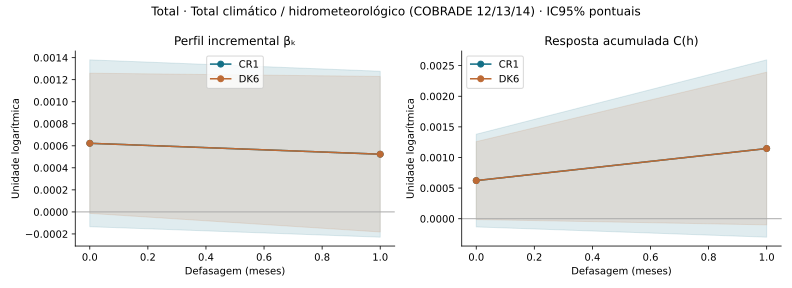

periodo       exposicao   nivel                                                  rotulo  K covariancia                            cenario  h  delta_x_inicial  resposta_delta_log_I  resposta_log_I_acumulada  variacao_relativa_I_pct   low_pct  high_pct
    Pré total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14)  1         CR1    aumento persistente D: 0 para 1  0         0.693147              0.000096                  0.000096                 0.009613 -0.050665  0.069927
    Pré total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14)  1         CR1    aumento persistente D: 0 para 1  1         0.693147             -0.000140                 -0.000043                -0.004346 -0.114726  0.106155
    Pré total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14)  1         CR1    aumento persistente D: 0 para 1  2         0.693147              0.000000                 -0.000043                -0.004346 -0.114726  0.106

In [9]:
m.figures()
for per in m.PERIODS:
    emit('image/svg+xml',(m.FIG/(m.slug(per)+'_total_climatico.svg')).read_text())
print(pd.read_csv(m.OUT/'cenarios.csv').query("exposicao=='total_climatico' and covariancia=='CR1'").to_string(index=False))
m.manifest()
print(json.loads((m.OUT/'manifest.json').read_text())['versoes'])

**Revisão de suporte e testes conjuntos:** Onda de Frio pré foi bloqueada pela regra de suporte contemporâneo (4 UFs); em K24 suas regressoras alcançam 6 UFs e têm posto completo, sem garantir inferência confiável. Regra original mantida. Covariâncias CR1 padronizadas dos testes conjuntos têm condição aproximada 37.463 em Calor/Baixa Umidade total, 13.312 em Chuvas Intensas total e 8.627 no pré. P muito pequeno não constitui evidência conclusiva; 27 UFs não são igualmente informativas. Mantém-se a especificação nos casos inconclusivos com não rejeição KPSS, documentando também os casos desfavoráveis.

## 8. Conclusão e reprodução
A escolha de K é específica da exposição e recorte, na mesma amostra entre candidatos. O ganho é ampliar o horizonte sem impô-lo igualmente a todos desastres; o custo é perder meses e introduzir incerteza de seleção não incorporada aos IC usuais. O painel é estimável quando há suporte e rank, mas não é apresentado como validado. Associação temporal, precedência preditiva de Granger e causalidade são conceitos diferentes.

Exogeneidade estrita condiciona todo histórico de x e FE; origem natural não garante causalidade. Normalidade/homocedasticidade não são condições universais da consistência de MQO robusto. Almon não foi necessário; fórmulas corretas Z0=Σx e Zj=Σk^j x, β=Ba, Vβ=BV_aB′ ficam no protocolo histórico, com correções incorporadas ao capítulo.

Entradas nos caminhos do manifesto; instalar requirements-dlm-painel-log.lock.txt. Executar `python src/executar_notebook_painel_log.py notebooks/23_dlm_painel_selecao_aic_1a24.ipynb`, depois `python src/relatorio_dlm_painel_log_aic.py` e `python src/verificar_dlm_painel_log_aic.py`. O executor usa compile/exec em namespace compartilhado, com stdout e figuras reais, sem simular saídas. O notebook 22 e seus resultados ficam preservados.